In [47]:
import numpy as np 
import pandas as pd
from scipy.signal import find_peaks
from scipy.stats import linregress
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.optimize import fsolve

# Konstanten für Energieberechnung
hc_eV_nm = 1240  # h*c in eV*nm
h = 6.62607015e-34  # Plancksches Wirkungsquantum in Js (angepasst)
m_0 = 9.10938356e-31  # Elektronenmasse in kg (angepasst)
c= 299792458  # Lichtgeschwindigkeit in m/s (angepasst)
h_quer = h / (2 * np.pi)  # Reduziertes Plancksches Wirkungsquantum in Js (angepasst)


Peaks in L= 15:
 Anzahl der Peaks: 11
Peaks in L= 30:
 Anzahl der Peaks: 21
Peaks in L= 45:
 Anzahl der Peaks: 32
Peaks in L= 60:
 Anzahl der Peaks: 42
Peaks in L= 75:
 Anzahl der Peaks: 49
[ 1000.  2000.  3000.  4000.  5000.  6000.  7000.  8000.  9000. 10000.
 11000.]


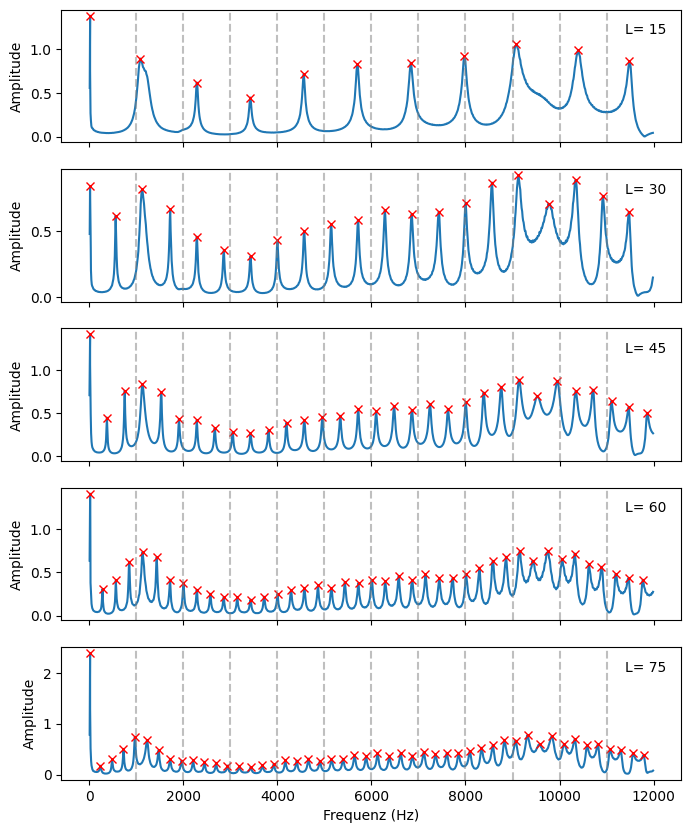

In [66]:
#Aufgabe 1 

df_ref= pd.read_csv(r"20-03-26\Ref.dat", skiprows=(0,1,2), sep="\t", decimal=",", names=["Frequenz", "Amplitude"])
#print(df_ref.head())

files= [r"20-03-26\2-15.dat", r"20-03-26\2-30.dat", r"20-03-26\2-45.dat", r"20-03-26\2-60.dat", r"20-03-26\2-75.dat" ]
längen= ["L= 15", "L= 30", "L= 45", "L= 60", "L= 75"]

peaks_15 = []
peaks_30 = []
peaks_45 = []
peaks_60 = []
peaks_75 = []
peaks_all= [peaks_15, peaks_30, peaks_45, peaks_60, peaks_75]

fig, axes = plt.subplots(5, 1, sharex=True, figsize=(8,10))

for i, file in enumerate(files): 
    df = pd.read_csv(file, skiprows=(0,1,2), sep="\t", decimal=",", names=["Frequenz", "Amplitude"])
    #print(df.head())
    
    frequency= df["Frequenz"]
    #frequency= frequency.iloc[3:] # Entfernen der ersten zwei Zeilen, die möglicherweise Störsignale enthalten
    amplitude= df["Amplitude"] / df_ref["Amplitude"] # Normierung der Amplitude mit der Referenz
    #amplitude= amplitude.iloc[3:]
    
    axes[i].plot(frequency, amplitude)
    axes[i].text(0.91, 0.9, längen[i], transform=axes[i].transAxes, verticalalignment='top')
    axes[i].set_ylabel("Amplitude")
    
    peaks, properties = find_peaks(
        amplitude,
        height=0.05,        # minimale Peak-Höhe (anpassen!)
        prominence=0.02,   # wie stark der Peak herausragt
        distance=1  )
    #  mit den Parametern werden alle Peaks gefunden! 
    #TODO hier eventuell noch mit Lorentz-Fit die Peaks genauer bestimmen
    

    print(f"Peaks in {längen[i]}:")
    print(f" Anzahl der Peaks: {len(peaks)}")
    axes[i].plot(frequency[peaks], amplitude[peaks], "x", color="red")  # Markieren der Peaks

    peaks_all[i] = np.array(frequency[peaks])
    
    
axes[-1].set_xlabel("Frequenz (Hz)")

reference_lines = np.linspace(1000,11000, 11)
print(reference_lines)

for ax in axes:
    for line in reference_lines:
        ax.axvline(line, linestyle="--", color="gray", alpha=0.5)  
        

plt.show()


[   20.01509  1083.48954  2294.44268  3424.11657  4563.03012  5704.25648
  6843.11302  7974.85902  9083.4418  10395.52402 11485.08651]
344.5147095818182


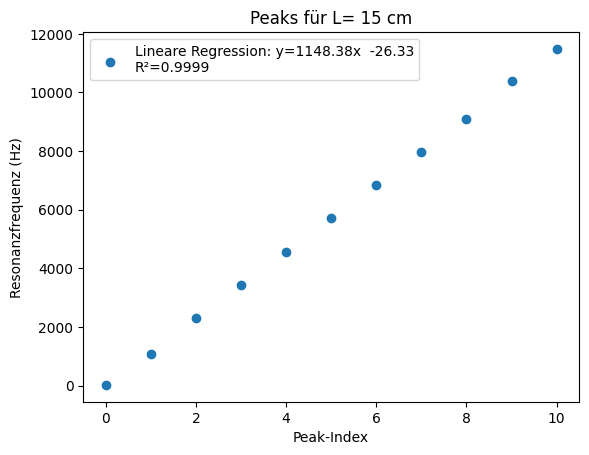

[   18.66038   562.79696  1123.35449  1722.79882  2291.95412  2863.92301
  3433.42003  4002.88585  4574.57452  5144.20426  5713.73249  6283.13983
  6854.8021   7433.77144  8005.30581  8565.39457  9125.59598  9765.36839
 10344.26704 10925.11236 11473.58355]
344.15388878181824


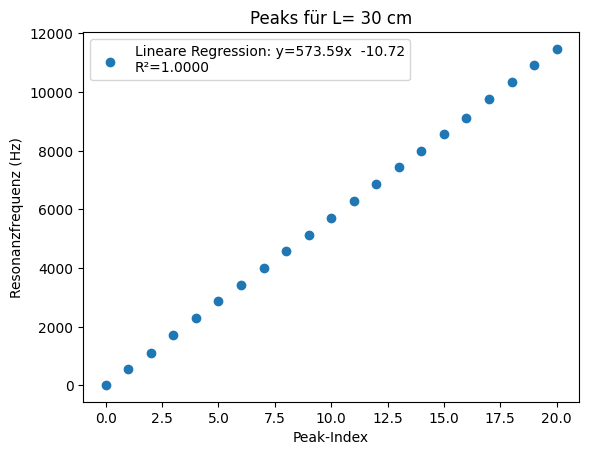

[   19.71208   376.71834   756.28148  1127.31937  1527.73109  1907.27182
  2286.93562  2666.78696  3048.55322  3428.10808  3816.8925   4196.74904
  4567.28188  4958.19773  5337.81509  5717.5582   6097.30872  6477.1556
  6858.75915  7247.71057  7627.44184  8007.18786  8388.88935  8757.21846
  9138.78018  9527.90856  9947.59279 10347.92666 10708.75701 11107.35634
 11467.96288 11868.60971]
344.1714295942082


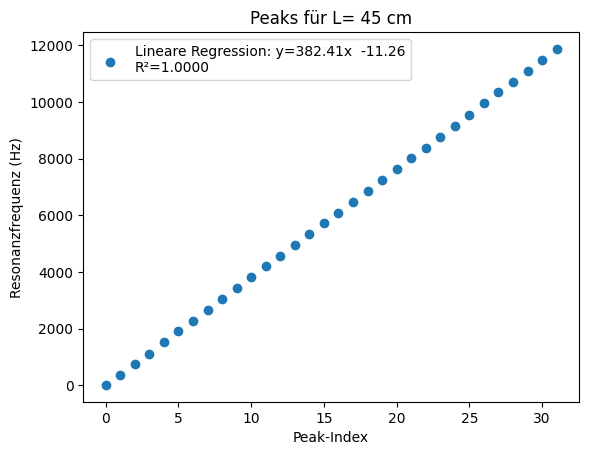

[   20.17015   283.91127   565.7455    853.84407  1135.79047  1435.38962
  1716.6619   2004.79971  2286.05785  2574.3206   2864.6532   3145.98995
  3434.11494  3715.63056  4005.87289  4296.48958  4575.54553  4865.99496
  5145.20923  5435.62207  5725.97144  6005.24927  6295.59422  6586.05907
  6865.16058  7146.35186  7446.09689  7725.19799  8006.30907  8296.70169
  8575.85424  8866.22446  9156.84564  9426.44836  9756.80488 10056.68189
 10326.24558 10626.106   10886.36401 11195.64724 11467.27941 11776.59387]
344.11102513734716


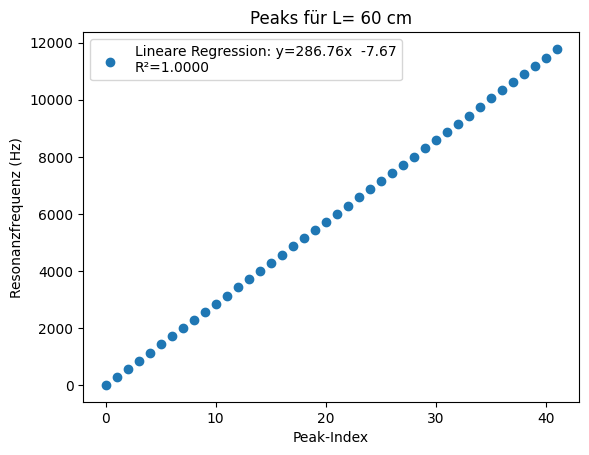

[   19.53061   239.44046   487.35818   728.88644   968.07319  1228.25375
  1478.67083  1718.0008   1968.38447  2207.72136  2448.95685  2697.4851
  2938.74709  3189.40143  3437.81897  3679.13746  3927.58803  4168.79885
  4417.4406   4658.65618  4909.24138  5148.51168  5399.0008   5638.29742
  5888.71846  6128.14299  6378.56342  6629.17845  6868.38806  7118.9652
  7358.27421  7599.44916  7848.11     8089.17765  8338.02492  8578.91818
  8827.95795  9068.69163  9319.35154  9579.44102  9839.53856 10098.04921
 10329.27044 10589.36033 10819.00517 11079.10178 11299.39459 11568.90088
 11789.14647]
368.7466703923469


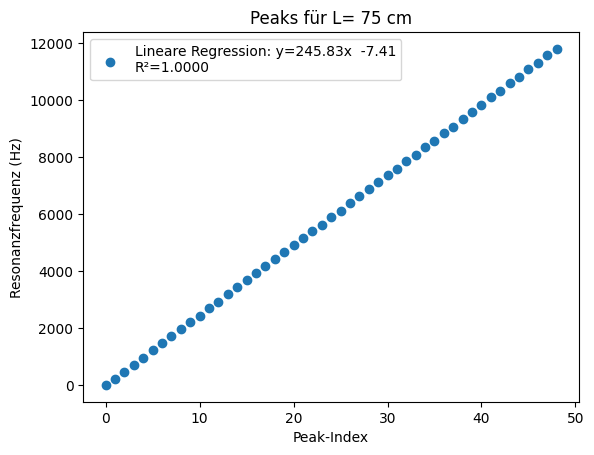

In [70]:
for i, peaks in enumerate(peaks_all):
    print(peaks)
    plt. scatter(np.arange(len(peaks)),peaks)
    plt. xlabel("Peak-Index")
    plt. ylabel("Resonanzfrequenz (Hz)")
    plt.title(f"Peaks für {längen[i]} cm")
    slope, intercept, r_value, p_value, std_err = linregress(np.arange(len(peaks)), peaks)
    print(slope* 2 * 0.15 * (i+1))
    plt.legend([f"Lineare Regression: y={slope:.2f}x  {intercept:+.2f}\nR²={r_value**2:.4f}"])
    plt.show()